## Unduh dan muat data

### Subtask:
Unduh dataset dari Kaggle menggunakan `kagglehub` dan muat data dari file CSV ke dalam Pandas DataFrame.


**Reasoning**:
Impor pustaka yang diperlukan, unduh dataset dari Kaggle, muat data ke dalam DataFrame, dan tampilkan beberapa baris pertama.



In [4]:
import kagglehub
import pandas as pd
import os

# Unduh dataset
dataset_path = kagglehub.dataset_download('prasetyawidiharsa/dataset-8-fitur-kualitas-air-jawa-timur-indonesia')

# Identifikasi nama file CSV
csv_file_name = None
for file_name in os.listdir(dataset_path):
    if file_name.endswith('.csv'):
        csv_file_name = file_name
        break

if csv_file_name:
    # Muat data ke dalam DataFrame
    csv_file_path = os.path.join(dataset_path, csv_file_name)
    df = pd.read_csv(csv_file_path)

    # Tampilkan beberapa baris pertama
    display(df.head())
else:
    print("No CSV file found in the downloaded dataset.")
    df = None


Using Colab cache for faster access to the 'dataset-8-fitur-kualitas-air-jawa-timur-indonesia' dataset.


,Temperatur,TDS,TSS,pH,BOD,COD,DO,CurahHujan,kelas
0,30.1,108.2,9.5,7.8,6.9,17.2,5.1,8.45,3
1,26.7,108.2,18.2,7.6,14.6,39.9,5.0,8.45,4
2,29.6,108.2,117.7,8.0,11.2,34.3,5.2,3.43,3
3,29.8,108.2,66.1,7.3,12.9,32.8,5.2,3.43,4
4,29.0,108.2,94.3,7.8,8.6,26.0,5.3,7.39,3


## Eksplorasi data

### Subtask:
Lakukan analisis data eksplorasi (EDA) untuk memahami struktur data, statistik deskriptif, dan distribusi fitur.


**Reasoning**:
Perform exploratory data analysis by checking data types, missing values, descriptive statistics, and unique values as requested by the instructions.



In [5]:
# 1. Tampilkan informasi umum tentang DataFrame df menggunakan .info()
print("Informasi Umum DataFrame:")
df.info()

# 2. Tampilkan statistik deskriptif dari kolom numerik dalam DataFrame df menggunakan .describe()
print("\nStatistik Deskriptif DataFrame:")
display(df.describe())

# 3. Hitung dan tampilkan jumlah nilai unik untuk setiap kolom dalam DataFrame df menggunakan .nunique()
print("\nJumlah Nilai Unik per Kolom:")
display(df.nunique())

# 4. Periksa dan tampilkan jumlah nilai yang hilang untuk setiap kolom dalam DataFrame df menggunakan .isnull().sum()
print("\nJumlah Nilai Hilang per Kolom:")
display(df.isnull().sum())

Informasi Umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperatur   213 non-null    float64
 1   TDS          213 non-null    float64
 2   TSS          213 non-null    float64
 3   pH           213 non-null    float64
 4   BOD          213 non-null    float64
 5   COD          213 non-null    float64
 6   DO           213 non-null    float64
 7   CurahHujan   213 non-null    float64
 8   kelas        213 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 15.1 KB

Statistik Deskriptif DataFrame:


,Temperatur,TDS,TSS,pH,BOD,COD,DO,CurahHujan,kelas
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,28.828638,404.405634,97.744601,7.267136,21.431690,92.529108,3.700235,4.431878,3.441315
std,1.334476,257.198722,134.669312,0.344567,40.745777,173.477325,1.534820,5.958623,0.631397
min,24.300000,107.000000,5.000000,6.400000,1.600000,10.500000,0.100000,0.000000,2.000000
25%,28.000000,227.600000,22.800000,7.000000,4.900000,22.100000,2.800000,0.330000,3.000000
50%,28.900000,299.000000,49.000000,7.200000,7.800000,26.400000,3.800000,2.460000,3.000000
75%,29.700000,624.000000,126.200000,7.500000,12.900000,48.000000,4.800000,6.290000,4.000000
max,33.400000,988.000000,965.000000,8.100000,321.800000,1366.000000,6.900000,37.500000,5.000000



Jumlah Nilai Unik per Kolom:


,0
Temperatur,56
TDS,18
TSS,161
pH,18
BOD,131
COD,166
DO,61
CurahHujan,87
kelas,4



Jumlah Nilai Hilang per Kolom:


,0
Temperatur,0
TDS,0
TSS,0
pH,0
BOD,0
COD,0
DO,0
CurahHujan,0
kelas,0


## Pra-pemrosesan data

### Subtask:
Tangani nilai yang hilang, encoding variabel kategorikal, dan penskalaan fitur jika diperlukan.


**Reasoning**:
Based on the previous EDA, there are no missing values. I will now check the data types, perform one-hot encoding if necessary, identify the numerical columns for scaling, and then scale the numerical features using StandardScaler.



In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 2. Periksa tipe data setiap kolom dan lakukan one-hot encoding jika diperlukan
print("Tipe data setiap kolom:")
print(df.dtypes)

# Based on the dtypes output from the previous EDA, the 'kelas' column is int64, which is not an object type,
# and all other columns are float64. There are no categorical columns that require one-hot encoding.
# Therefore, we skip the one-hot encoding step.

# 3. Identifikasi kolom numerik yang akan digunakan untuk klastering (semua kolom kecuali 'kelas')
numerical_cols = df.columns.tolist()
numerical_cols.remove('kelas')
print(f"\nKolom numerik untuk klastering: {numerical_cols}")

# 4. Lakukan penskalaan fitur pada kolom numerik menggunakan StandardScaler
scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(df[numerical_cols])

# Simpan DataFrame yang telah di-prapemprosesan dalam variabel baru
df_scaled = pd.DataFrame(df_scaled_values, columns=numerical_cols)

# Add the 'kelas' column back to the scaled DataFrame
df_scaled['kelas'] = df['kelas']

# 5. Tampilkan beberapa baris pertama dari DataFrame yang telah di-prapemprosesan
print("\nDataFrame setelah penskalaan:")
display(df_scaled.head())

Tipe data setiap kolom:
Temperatur     float64
TDS            float64
TSS            float64
pH             float64
BOD            float64
COD            float64
DO             float64
CurahHujan     float64
kelas            int64
dtype: object

Kolom numerik untuk klastering: ['Temperatur ', 'TDS', 'TSS', 'pH', 'BOD', 'COD', 'DO', 'CurahHujan']

DataFrame setelah penskalaan:


,Temperatur,TDS,TSS,pH,BOD,COD,DO,CurahHujan,kelas
0,0.954949,-1.154374,-0.656812,1.550118,-0.357483,-0.435253,0.914155,0.675926,3
1,-1.598869,-1.154374,-0.592058,0.968312,-0.168061,-0.304092,0.848847,0.675926,4
2,0.579387,-1.154374,0.148530,2.131925,-0.251702,-0.336449,0.979462,-0.168535,3
3,0.729612,-1.154374,-0.235534,0.095602,-0.209882,-0.345116,0.979462,-0.168535,4
4,0.128714,-1.154374,-0.025638,1.550118,-0.315663,-0.384407,1.044770,0.497613,3


## Pemilihan fitur

### Subtask:
Pilih fitur yang relevan untuk klastering dan pemodelan.


**Reasoning**:
Identify the feature columns from `df_scaled` by excluding the 'kelas' column, create a new DataFrame `df_features` with these columns, display the column names of `df_features`, and then display the first few rows of `df_features`.



In [7]:
# Identifikasi kolom fitur (semua kolom kecuali 'kelas')
feature_cols = df_scaled.columns.tolist()
feature_cols.remove('kelas')

# Buat DataFrame baru dengan hanya kolom fitur yang dipilih
df_features = df_scaled[feature_cols]

# Tampilkan nama kolom yang dipilih
print("Kolom fitur yang dipilih untuk klastering dan pemodelan:")
print(df_features.columns.tolist())

# Tampilkan beberapa baris pertama dari df_features
print("\nBeberapa baris pertama dari DataFrame fitur:")
display(df_features.head())

Kolom fitur yang dipilih untuk klastering dan pemodelan:
['Temperatur ', 'TDS', 'TSS', 'pH', 'BOD', 'COD', 'DO', 'CurahHujan']

Beberapa baris pertama dari DataFrame fitur:


,Temperatur,TDS,TSS,pH,BOD,COD,DO,CurahHujan
0,0.954949,-1.154374,-0.656812,1.550118,-0.357483,-0.435253,0.914155,0.675926
1,-1.598869,-1.154374,-0.592058,0.968312,-0.168061,-0.304092,0.848847,0.675926
2,0.579387,-1.154374,0.148530,2.131925,-0.251702,-0.336449,0.979462,-0.168535
3,0.729612,-1.154374,-0.235534,0.095602,-0.209882,-0.345116,0.979462,-0.168535
4,0.128714,-1.154374,-0.025638,1.550118,-0.315663,-0.384407,1.044770,0.497613


## Klastering

### Subtask:
Terapkan algoritma klastering (misalnya, K-Means) untuk mengelompokkan lokasi berdasarkan fitur kualitas air.


**Reasoning**:
Apply the KMeans clustering algorithm to the features and add the resulting cluster labels to the original dataframe.



In [8]:
from sklearn.cluster import KMeans

# Instantiate KMeans with a reasonable number of clusters (e.g., 4) and set random_state
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the KMeans model to the df_features DataFrame
kmeans.fit(df_features)

# Get the cluster labels
cluster_labels = kmeans.labels_

# Add the cluster labels as a new column named 'cluster_label' to the original df DataFrame
df['cluster_label'] = cluster_labels

# Display the first few rows of the updated df DataFrame to show the new column
print("DataFrame with added cluster labels:")
display(df.head())

DataFrame with added cluster labels:


,Temperatur,TDS,TSS,pH,BOD,COD,DO,CurahHujan,kelas,cluster_label
0,30.1,108.2,9.5,7.8,6.9,17.2,5.1,8.45,3,0
1,26.7,108.2,18.2,7.6,14.6,39.9,5.0,8.45,4,0
2,29.6,108.2,117.7,8.0,11.2,34.3,5.2,3.43,3,0
3,29.8,108.2,66.1,7.3,12.9,32.8,5.2,3.43,4,0
4,29.0,108.2,94.3,7.8,8.6,26.0,5.3,7.39,3,0


## Pemodelan machine learning

### Subtask:
Bangun model machine learning untuk memprediksi kualitas air atau melakukan tugas klasifikasi/regresi lainnya berdasarkan klaster atau fitur.


**Reasoning**:
Import necessary libraries, define features and target, split data, initialize and train the model, and make predictions.



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# Use all columns in df except 'kelas' and 'cluster_label' as features and 'kelas' as the target.
X = df.drop(['kelas', 'cluster_label'], axis=1)
y = df['kelas']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

**Reasoning**:
Evaluate the performance of the trained model using accuracy score and classification report.



In [10]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 0.953125
Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.95      1.00      0.97        36
           4       0.96      0.96      0.96        24
           5       1.00      0.67      0.80         3

    accuracy                           0.95        64
   macro avg       0.73      0.66      0.68        64
weighted avg       0.94      0.95      0.94        64



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Visualisasi hasil

### Subtask:
Visualisasikan hasil pemodelan dan analisis.


**Reasoning**:
Create a new DataFrame combining the actual and predicted water quality classes from the test set for comparison and then generate a scatter plot to visualize this comparison.



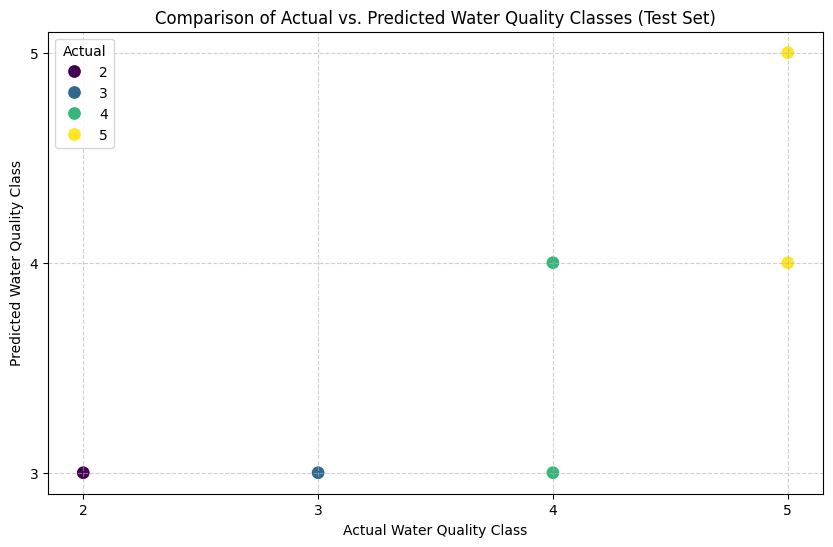

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Buat DataFrame baru yang menggabungkan y_test dan y_pred
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# 2. Gunakan matplotlib.pyplot atau seaborn untuk membuat visualisasi perbandingan
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=comparison_df, hue='Actual', palette='viridis', s=100)

# 3. Pastikan visualisasi memiliki label sumbu yang jelas dan judul yang informatif.
plt.title('Comparison of Actual vs. Predicted Water Quality Classes (Test Set)')
plt.xlabel('Actual Water Quality Class')
plt.ylabel('Predicted Water Quality Class')
plt.xticks(sorted(comparison_df['Actual'].unique()))
plt.yticks(sorted(comparison_df['Predicted'].unique()))
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Tampilkan plot yang dihasilkan.
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset contains 213 entries and 9 columns, with no missing values.
*   All columns are numerical (`float64` or `int64`).
*   Features were scaled using `StandardScaler` before clustering.
*   K-Means clustering with 4 clusters was applied, and cluster labels were added to the original DataFrame.
*   Visualization of clusters on a map was not possible due to the lack of geographical coordinates (latitude and longitude) in the dataset.
*   A RandomForestClassifier model was trained to predict water quality class ('kelas').
*   The model achieved an accuracy of 0.953 on the test set.
*   The classification report indicated good performance for classes 3 and 4, but limited performance for classes 2 and 5, likely due to the small sample size of these classes in the test set.
*   A scatter plot was generated to visualize the comparison between actual and predicted water quality classes on the test set.

### Insights or Next Steps

*   Investigate the possibility of obtaining or approximating geographical coordinates for the locations in the dataset to enable spatial visualization of the clusters.
*   Explore techniques to address class imbalance, such as resampling methods or using evaluation metrics more robust to imbalance, to improve the model's performance on minority classes.
